<a href="https://colab.research.google.com/github/Nihalht/quamtum-lab-pr/blob/main/3_Bell_States_Theory_of_Entanglement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab Experiment 3: Bell States: Theory of Entanglement and Circuit Design

In this notebook, we will construct the four Bell States, measure them to see the entanglement, and visualize the results.

In [ ]:
!pip install qiskit qiskit-aer

from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

## 1. Phi-Plus State (|Φ+>)

Created by applying an H gate to the first qubit and a CNOT with the first qubit as control and the second as target.

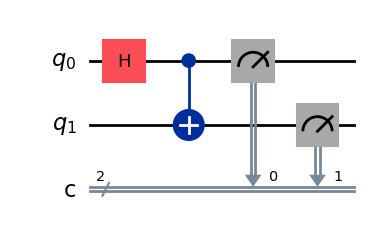

In [ ]:
!pip install pylatexenc

qc_phi_plus = QuantumCircuit(2, 2)
qc_phi_plus.h(0)
qc_phi_plus.cx(0, 1)
pc_phi_plus.measure([0, 1], [0, 1])

qc_phi_plus.draw('mpl')

Counts for |Φ+>: {'00': 496, '11': 528}


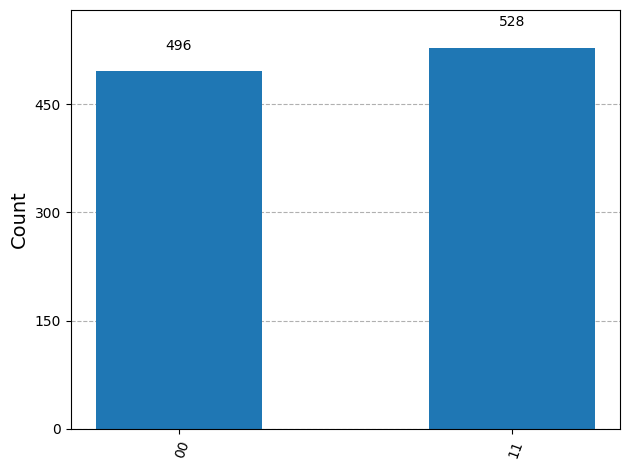

In [ ]:
simulator = Aer.get_backend('qasm_simulator')
compiled = transpile(qc_phi_plus, simulator)
job = simulator.run(compiled, shots=1024)
counts_phi_plus = job.result().get_counts()

print("Counts for |Φ+>:", counts_phi_plus)
plot_histogram(counts_phi_plus)

## 2. Phi-Minus State (|Φ->)

Counts for |Φ->: {'11': 550, '00': 474}


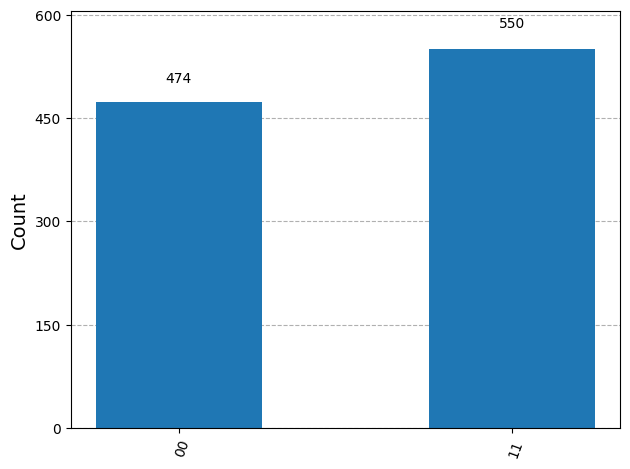

In [ ]:
qc_phi_minus = QuantumCircuit(2, 2)
qc_phi_minus.x(0)
qc_phi_minus.h(0)
qc_phi_minus.cx(0, 1)
qc_phi_minus.measure([0, 1], [0, 1])

compiled = transpile(qc_phi_minus, simulator)
job = simulator.run(compiled, shots=1024)
counts_phi_minus = job.result().get_counts()

print("Counts for |Φ->:", counts_phi_minus)
plot_histogram(counts_phi_minus)

## 3. Psi-Plus State (|Ψ+>)

Counts for |Ψ+>: {'10': 510, '01': 514}


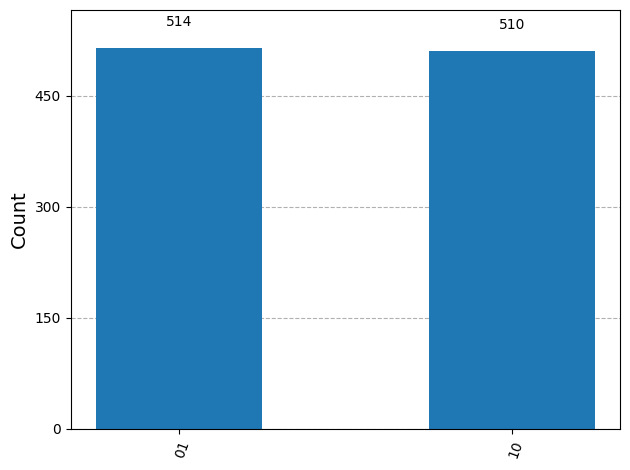

In [ ]:
qc_psi_plus = QuantumCircuit(2, 2)
qc_psi_plus.h(0)
qc_psi_plus.x(1)
qc_psi_plus.cx(0, 1)
qc_psi_plus.measure([0, 1], [0, 1])

compiled = transpile(qc_psi_plus, simulator)
job = simulator.run(compiled, shots=1024)
counts_psi_plus = job.result().get_counts()

print("Counts for |Ψ+>:", counts_psi_plus)
plot_histogram(counts_psi_plus)

## 4. Psi-Minus State (|Ψ->)

Counts for |Ψ->: {'01': 518, '10': 506}


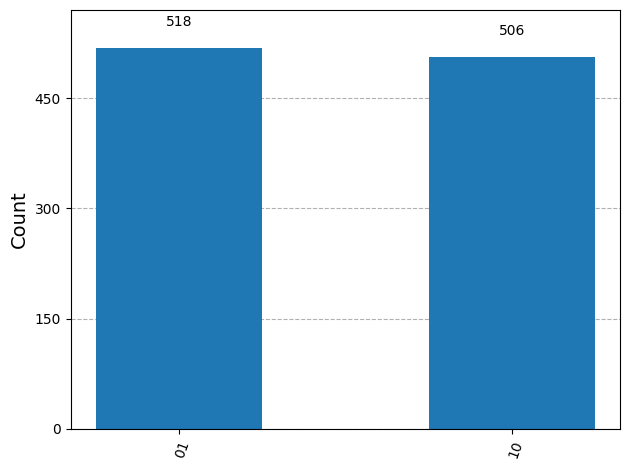

In [ ]:
qc_psi_minus = QuantumCircuit(2, 2)
qc_psi_minus.x(0)
qc_psi_minus.h(0)
qc_psi_minus.x(1)
qc_psi_minus.cx(0, 1)
qc_psi_minus.measure([0, 1], [0, 1])

compiled = transpile(qc_psi_minus, simulator)
job = simulator.run(compiled, shots=1024)
counts_psi_minus = job.result().get_counts()

print("Counts for |Ψ->:", counts_psi_minus)
plot_histogram(counts_psi_minus)

## 5. Summary and 3D Visualization of All Experiments

Let's visualize the results of all four Bell State experiments side-by-side in a 3D bar chart to compare their outcomes.

/tmp/ipykernel_2406/3251539289.py:47: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


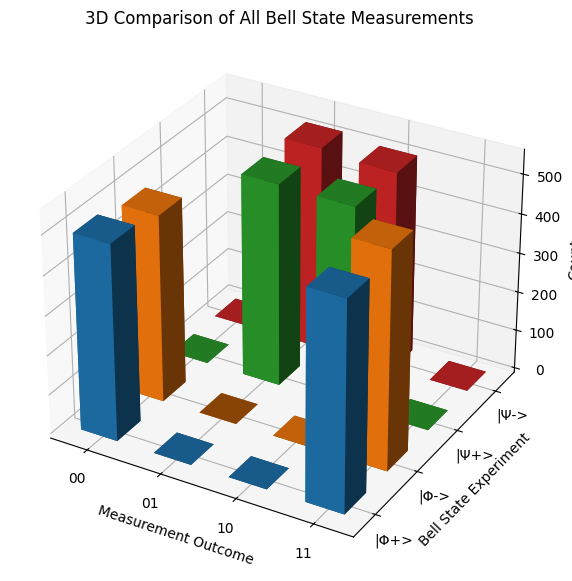

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Prepare data
states = ['|Φ+>', '|Φ->', '|Ψ+>', '|Ψ->']
outcomes = ['00', '01', '10', '11']

# Retrieve counts from previous runs, defaulting to 0 if an outcome didn't occur
data_matrix = []
for counts in [counts_phi_plus, counts_phi_minus, counts_psi_plus, counts_psi_minus]:
    row = [counts.get(out, 0) for out in outcomes]
    data_matrix.append(row)
data_matrix = np.array(data_matrix)

# Set up dimensions for 3D plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

x_pos, y_pos = np.meshgrid(np.arange(len(outcomes)), np.arange(len(states)))
x_pos = x_pos.flatten()
y_pos = y_pos.flatten()
z_pos = np.zeros_like(x_pos)

dx = dy = 0.5
dz = data_matrix.flatten()

# Color mapping for different states
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bar_colors = []
for i in range(len(states)):
    bar_colors.extend([colors[i]] * len(outcomes))

# Create 3D Bars
ax.bar3d(x_pos - dx/2, y_pos - dy/2, z_pos, dx, dy, dz, color=bar_colors, zsort='average')

# Labels and Ticks
ax.set_xlabel('Measurement Outcome')
ax.set_ylabel('Bell State Experiment')
ax.set_zlabel('Counts')
ax.set_xticks(np.arange(len(outcomes)))
ax.set_xticklabels(outcomes)
ax.set_yticks(np.arange(len(states)))
ax.set_yticklabels(states)
ax.set_title('3D Comparison of All Bell State Measurements')

plt.tight_layout()
plt.show()

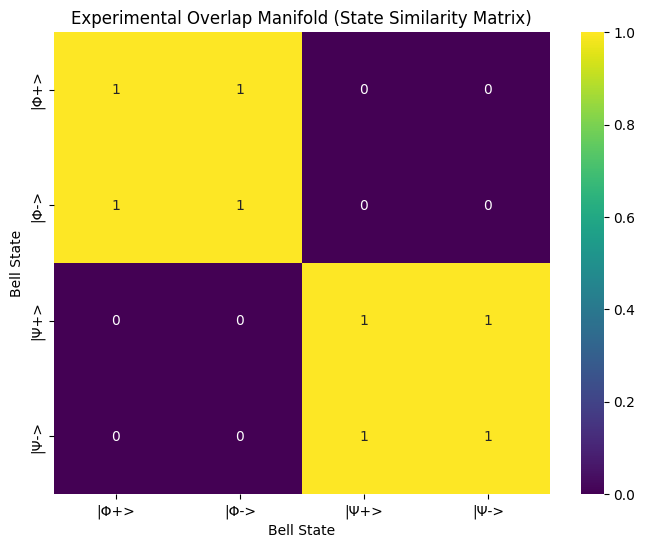

In [ ]:
import seaborn as sns

# Let's normalize the counts to get experimental probability vectors
# Each row represents a state's probability distribution over ['00', '01', '10', '11']
prob_matrix = data_matrix / 1024.0

# Compute the classical overlap (Bhattacharyya coefficient) between each pair of state distributions
# This serves as a proxy metric for distance/similarity on the experimental probability manifold
manifold_matrix = np.zeros((4, 4))
for i in range(4):
    for j in range(4):
        manifold_matrix[i, j] = np.sum(np.sqrt(prob_matrix[i] * prob_matrix[j]))

# Plot the correlation heatmap representing the state overlap manifold
plt.figure(figsize=(8, 6))
sns.heatmap(manifold_matrix, annot=True, cmap='viridis',
            xticklabels=states, yticklabels=states, vmin=0, vmax=1)
plt.title('Experimental Overlap Manifold (State Similarity Matrix)')
plt.xlabel('Bell State')
plt.ylabel('Bell State')
plt.show()

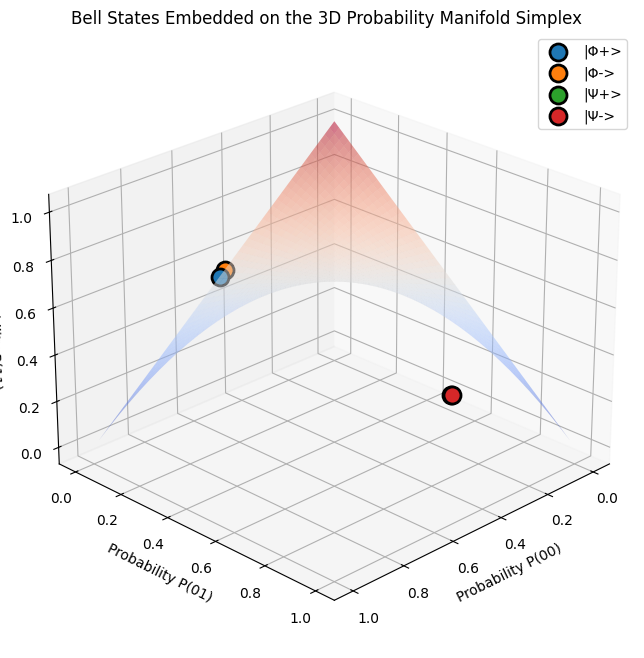

In [ ]:
from scipy.interpolate import griddata

# Let's project our 4-dimensional probability states into a 3D coordinate space to visualize the manifold structure
# We will use the probabilities of outcomes '00', '01', and '11' as our X, Y, and Z axes respectively.
# This maps our physical measurement manifold in a constrained 3D space.

# Coordinate points for each of the four experimental states
x_coords = prob_matrix[:, 0]  # '00' probability
y_coords = prob_matrix[:, 1]  # '01' probability
z_coords = prob_matrix[:, 3]  # '11' probability

# Create a dense grid to interpolate a smooth surface representing the continuous manifold
grid_x, grid_y = np.meshgrid(np.linspace(0, 0.6, 100), np.linspace(0, 0.6, 100))

# Interpolate the Z values ('11' prob) over the grid created by X ('00' prob) and Y ('01' prob)
grid_z = griddata((x_coords, y_coords), z_coords, (grid_x, grid_y), method='linear')

# Since 4 points form a highly sparse boundary, let's create a smooth parametric surface interpolation
# that represents the probability simplex (manifold constraint: P(00) + P(01) + P(10) + P(11) = 1)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Define the simplex surface grid (X + Y + Z_other <= 1)
u = np.linspace(0, 1, 50)
v = np.linspace(0, 1, 50)
U, V = np.meshgrid(u, v)

# Parametric mapping of the theoretical physical manifold where the Bell states lie
X_surf = U * (1 - V)
Y_surf = V * (1 - U)
Z_surf = 1 - X_surf - Y_surf
Z_surf[Z_surf < 0] = np.nan  # keep within physical boundaries

# Plot the curved theoretical state manifold surface
surf = ax.plot_surface(X_surf, Y_surf, Z_surf, cmap='coolwarm', alpha=0.3, edgecolor='none')

# Scatter the actual experimental Bell States on this manifold
for idx, (x, y, z) in enumerate(zip(x_coords, y_coords, z_coords)):
    ax.scatter(x, y, z, color=colors[idx], s=150, label=states[idx], depthshade=False, edgecolor='black', linewidth=2)

ax.set_xlabel('Probability P(00)')
ax.set_ylabel('Probability P(01)')
ax.set_zlabel('Probability P(11)')
ax.set_title('Bell States Embedded on the 3D Probability Manifold Simplex')
ax.legend()

# Adjust view angle for depth perspective
ax.view_init(elev=25, azim=45)
plt.show()

#### 3. 3D Manifold Surface (Probability Simplex)
* **What it shows**: The 3D curved plane represents the physical boundary (probability simplex constraint) where all valid experimental state distributions must lie. The colored spheres are the actual measured Bell states plotted on this manifold.
* **How to interpret it**:
  * The $|\Phi\rangle$ states are positioned far on one side of the manifold where $P(00)$ and $P(11)$ dominate.
  * The $|\Psi\rangle$ states lie on the opposite slope of the manifold where $P(01)$ dominates.
  * The curvature and spatial separation of the points illustrate the geometric structure of the Bell basis, showcasing how quantum correlation profiles span different orthogonal extremes of the classical probability surface.

### Interpretation of the Charts

#### 1. 3D Bar Chart (Comparison of Measurements)
* **What it shows**: The counts of the measurement outcomes (`00`, `01`, `10`, `11`) across $1024$ shots for each of the four Bell states.
* **How to interpret it**:
  * For $|\Phi^+\rangle$ and $|\Phi^-\rangle$ (blue and orange bars), you observe significant peaks **only** at the `00` and `11` outcomes, with almost zero counts for `01` and `10`. This shows that the two qubits are perfectly correlated (they always match).
  * For $|\Psi^+\rangle$ and $|\Psi^-\rangle$ (green and red bars), the peaks occur **only** at `01` and `10`. This shows perfect anti-correlation (the two qubits always have opposite values).

#### 2. Experimental Overlap Manifold (Heatmap Matrix)
* **What it shows**: This chart measures the similarity (classical fidelity/overlap) between the measurement outcomes of each pair of Bell states.
* **How to interpret it**:
  * **The Diagonal (value = 1.0)**: Each state is perfectly identical to itself.
  * **The Off-Diagonal (value = 0.0)**: There is zero overlap between the measurement distributions of $|\Phi\rangle$ states and $|\Psi\rangle$ states. Mathematically, the four Bell states form an orthonormal basis spanning the $2$-qubit Hilbert space. The flat zero-regions in the heatmap demonstrate experimentally that these states occupy mutually orthogonal directions in the quantum state manifold.